**DSA506 - Visual Analytics and Communications**  
**Final Test - Problem 3**  
**Michelle Richardson**  

**Import and Cleaning**  

Import lyrics data set from Hugging Face, filter it, and save as csv file. 

In [ ]:
#from datasets import load_dataset
#from datasets import concatenate_datasets

#ds = load_dataset("theelderemo/genius-lyrics-cleaned", split="train")

#green_day = (
#    ds.filter(lambda x: x["artist"] == "Green Day")
#      .shuffle(seed=42)
#      .select(range(10))
#)

#taylor = (
#    ds.filter(lambda x: x["artist"] == "Taylor Swift")
#      .shuffle(seed=42)
#      .select(range(10))
#)

#sample = concatenate_datasets([green_day, taylor])
#df = sample.to_pandas().reset_index(drop=True)
#df.to_csv('data/music.csv')

In [39]:
import pandas as pd
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud
from textblob import TextBlob
import matplotlib.pyplot as plt
import seaborn as sns

In [55]:
df = pd.read_csv('data/music.csv')
#df

Look at keywords inside square brackets. 

In [56]:
keywords = (df['lyrics'].str.findall(r'\[([^\]]+)\]').explode().dropna())
keywords.unique()

<ArrowStringArray>
[                'Verse 1',                  'Chorus',
                 'Verse 2',                  'Bridge',
           'Instrumentals',               'ST. JIMMY',
    'ST. JIMMY and JOHNNY',         'THEO and GERARD',
                     'ALL',                  'JOHNNY',
         'JOHNNY and WILL',                    'WILL',
                  'MIGUEL',      'MIGUEL and HEATHER',
                 'HEATHER',        'JOHNNY and TUNNY',
         'WILL and JOHNNY', 'JOHNNY, TUNNY, and WILL',
                   'TUNNY',                 'COMPANY',
              'ENSEMBLE 1',              'ENSEMBLE 2',
         'FEMALE ENSEMBLE',                   'Intro',
                 'Whistle',                 'Verse 3',
                   'Outro',     'Instrumental Bridge',
    '"Extraordinary Girl"',      'Instrumental Intro',
      'Instrumental Break',                'Chorus 2',
            '"Letterbomb"',  'Intro - Kathleen Hanna',
              'Pre-Chorus',                  '

Remove keywords, replace '\n' with spaces, remove punctuation, change to lower case.

In [57]:
punctuation = string.punctuation.replace("'", "")

df['lyrics_clean'] = (
    df['lyrics']
    .str.replace(r'\[[^\]]+\]', "", regex=True)  # remove keywords in square brackets
    .str.replace('\n', " ", regex=False)         # replace \n with space
    .str.lower()
    .str.replace(f'[{punctuation}]', ' ', regex=True)  # remove punctuation except apostrophes
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

In [58]:
df

,title,artist,tag,year,lyrics,lyrics_clean
0,Holy Toledo,Green Day,rock,2021,[Verse 1]\nI wanna go where the trouble begins...,i wanna go where the trouble begins and the mo...
1,Homecoming Broadway,Green Day,rock,2010,I. The Death of St. Jimmy\n\n[ST. JIMMY]\nMy h...,i the death of st jimmy my heart is beating fr...
2,Fell For You Demo,Green Day,rock,2014,I woke up in a pool of sweat\nFirst I thought ...,i woke up in a pool of sweat first i thought t...
3,American Idiot Broadway,Green Day,rock,2010,[JOHNNY]\nDon't want to be an American idiot\n...,don't want to be an american idiot don't want ...
4,Walking The Dog,Green Day,rock,2020,[Intro]\nRolling\nBong it\nTake 5\n\n[Verse 1]...,rolling bong it take 5 mary mac dressed in bla...
5,Stuart and the Ave.,Green Day,rock,1995,[Verse 1]\nStanding on the corner of Stuart an...,standing on the corner of stuart and the avenu...
6,Stay the Night Acoustic,Green Day,rock,2014,Well I ain't got much time so I'll get to the ...,well i ain't got much time so i'll get to the ...
7,Ashley Demo,Green Day,rock,2014,"1,2!\n\nASHLEY!\nAre you running around?\nAre ...",1 2 ashley are you running around are you cryi...
8,Thats Alright,Green Day,rock,2009,"Well now, that's all right, now mama\nThat's a...",well now that's all right now mama that's all ...
9,Extraordinary Girl / Letterbomb,Green Day,rock,2004,"[""Extraordinary Girl""]\n\n[Instrumental Intro]...",she's an extraordinary girl in an ordinary wor...


In [59]:
#stop_words = set(stopwords.words("english"))
#stop_words

I did not want to use the full list of standard stopwords because it might affect the analysis, so I came up with my own list. 

In [60]:
my_stopwords = {'a','an','the','from','of','in','it','so','that'}

df['lyrics_clean'] = (
    df['lyrics_clean']
    .apply(lambda x: " ".join(
        word for word in x.split()
        if word not in my_stopwords
    ))
)


In [61]:
df

,title,artist,tag,year,lyrics,lyrics_clean
0,Holy Toledo,Green Day,rock,2021,[Verse 1]\nI wanna go where the trouble begins...,i wanna go where trouble begins and morning af...
1,Homecoming Broadway,Green Day,rock,2010,I. The Death of St. Jimmy\n\n[ST. JIMMY]\nMy h...,i death st jimmy my heart is beating me i am s...
2,Fell For You Demo,Green Day,rock,2014,I woke up in a pool of sweat\nFirst I thought ...,i woke up pool sweat first i thought i pissed ...
3,American Idiot Broadway,Green Day,rock,2010,[JOHNNY]\nDon't want to be an American idiot\n...,don't want to be american idiot don't want nat...
4,Walking The Dog,Green Day,rock,2020,[Intro]\nRolling\nBong it\nTake 5\n\n[Verse 1]...,rolling bong take 5 mary mac dressed black sil...
5,Stuart and the Ave.,Green Day,rock,1995,[Verse 1]\nStanding on the corner of Stuart an...,standing on corner stuart and avenue ripping u...
6,Stay the Night Acoustic,Green Day,rock,2014,Well I ain't got much time so I'll get to the ...,well i ain't got much time i'll get to point d...
7,Ashley Demo,Green Day,rock,2014,"1,2!\n\nASHLEY!\nAre you running around?\nAre ...",1 2 ashley are you running around are you cryi...
8,Thats Alright,Green Day,rock,2009,"Well now, that's all right, now mama\nThat's a...",well now that's all right now mama that's all ...
9,Extraordinary Girl / Letterbomb,Green Day,rock,2004,"[""Extraordinary Girl""]\n\n[Instrumental Intro]...",she's extraordinary girl ordinary world and sh...


**Green Day**  

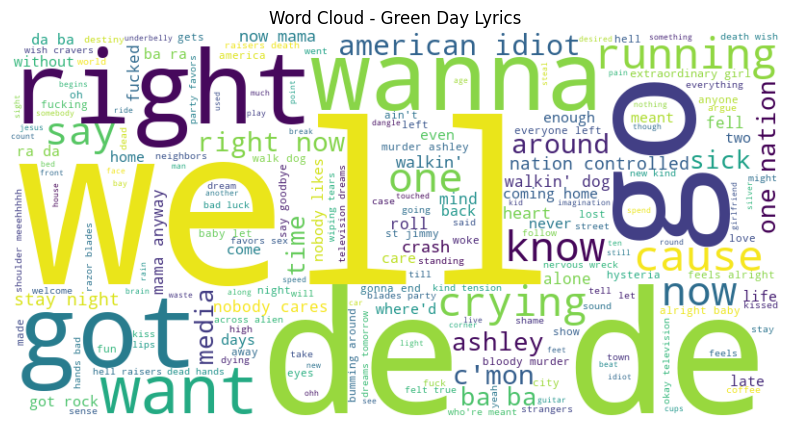

In [62]:
green_day = df[df['artist']=='Green Day']

filtered_text = " ".join(list(green_day['lyrics_clean']))
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(filtered_text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud - Green Day Lyrics")
plt.show()

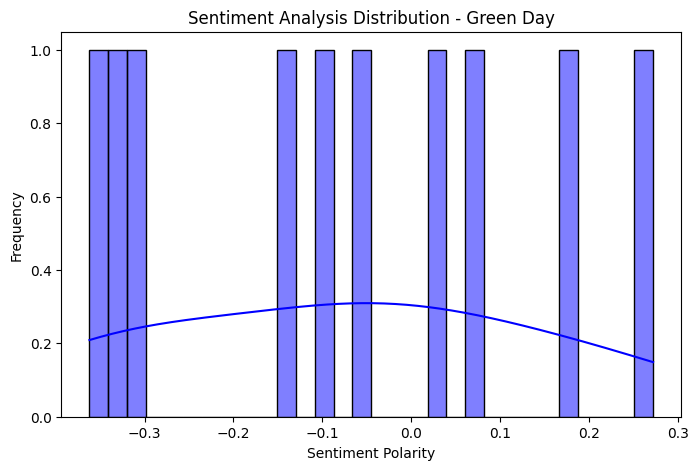

In [63]:
green_day["Sentiment"] = green_day["lyrics_clean"].apply(lambda x: TextBlob(x).sentiment.polarity)

# Plot sentiment distribution
plt.figure(figsize=(8, 5))
sns.histplot(green_day["Sentiment"], bins=30, kde=True, color='blue')
plt.title("Sentiment Analysis Distribution - Green Day")
plt.xlabel("Sentiment Polarity")
plt.ylabel("Frequency")
plt.show()

Sentiment analysis for Green Day is fairly neutral, but weighted a little more toward the negative. Since they started out singing about teen angst and suburban boredom.  

Find the number of unique words per song.  

In [64]:
green_day['Unique_Words'] = green_day['lyrics_clean'].apply(
    lambda x: len(set(x.split()))
)

green_day[['title', 'Unique_Words']]

,title,Unique_Words
0,Holy Toledo,76
1,Homecoming Broadway,283
2,Fell For You Demo,76
3,American Idiot Broadway,65
4,Walking The Dog,77
5,Stuart and the Ave.,72
6,Stay the Night Acoustic,72
7,Ashley Demo,67
8,Thats Alright,63
9,Extraordinary Girl / Letterbomb,169


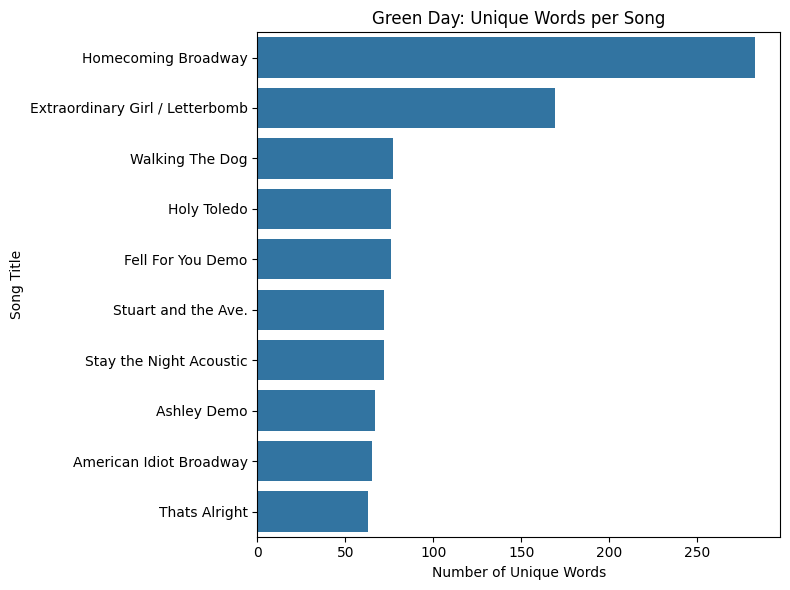

In [65]:
plt.figure(figsize=(8, 6))

sns.barplot(
    data=green_day.sort_values('Unique_Words',ascending=False),
    y='title',
    x='Unique_Words'
)

plt.title('Green Day: Unique Words per Song')
plt.xlabel('Number of Unique Words')
plt.ylabel('Song Title')

plt.tight_layout()
plt.show()

Green Day uses 75 or less unique words (using cleaned lyrics without some stop words) per song, but Homecoming Broadway has about 280! Extraordinary Girl/Letterbomb has the second highest number. Both of these songs have more words than any of Taylor's 10, but the remaining eight have fewer. 

**Taylor Swift**  

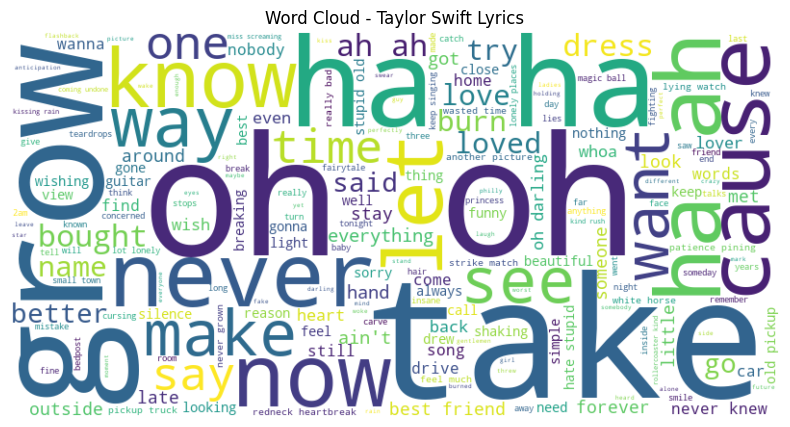

In [66]:
taylor = df[df['artist']=='Taylor Swift']

filtered_text = " ".join(list(taylor['lyrics_clean']))
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(filtered_text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud - Taylor Swift Lyrics")
plt.show()

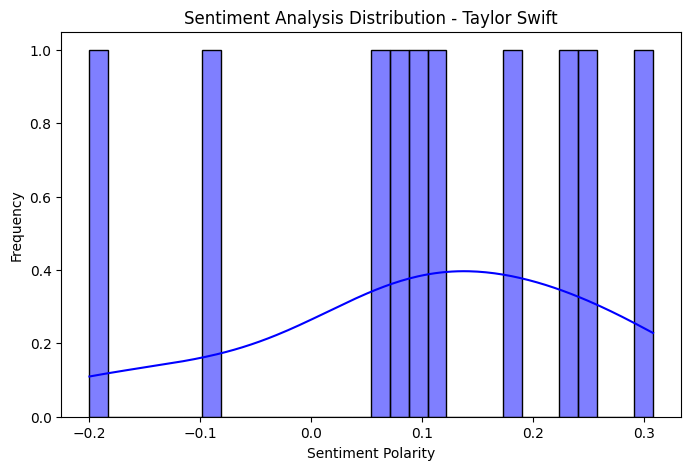

In [67]:
taylor["Sentiment"] = taylor["lyrics_clean"].apply(lambda x: TextBlob(x).sentiment.polarity)

# Plot sentiment distribution
plt.figure(figsize=(8, 5))
sns.histplot(taylor["Sentiment"], bins=30, kde=True, color='blue')
plt.title("Sentiment Analysis Distribution - Taylor Swift")
plt.xlabel("Sentiment Polarity")
plt.ylabel("Frequency")
plt.show()

Taylor's lyrics are also fairly neutral in range, but weighted on the positive side. I would have expected more negativity, because she often sings about breakups.

In [68]:
taylor['Unique_Words'] = taylor['lyrics_clean'].apply(
    lambda x: len(set(x.split()))
)

taylor[['title', 'Unique_Words']]

,title,Unique_Words
10,magic ball,122
11,Picture to Burn,101
12,Teardrops on My Guitar Live from SoHo,125
13,Dress,119
14,Who Knew / Unpretty,120
15,Never Grow Up,147
16,The Outside,83
17,Lover Live from Paris,110
18,White Horse,120
19,The Way I Loved You Taylors Version,111


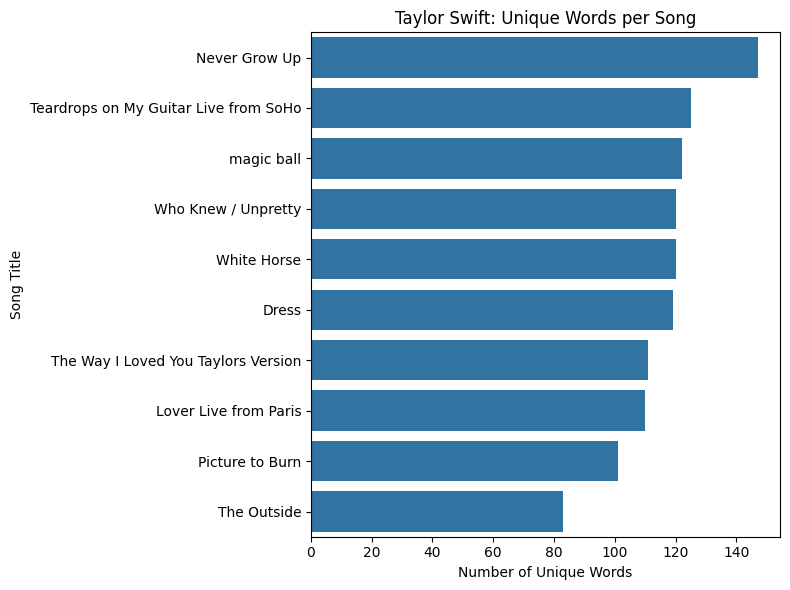

In [69]:
plt.figure(figsize=(8, 6))

sns.barplot(
    data=taylor.sort_values('Unique_Words',ascending=False),
    y='title',
    x='Unique_Words'
)

plt.title('Taylor Swift: Unique Words per Song')
plt.xlabel('Number of Unique Words')
plt.ylabel('Song Title')

plt.tight_layout()
plt.show()

Taylor Swift's ten songs have more consistency in vocabulary range, from about 80 to 150. Her lowest two are from earlier in her career, and are also in the country, not pop, genre.  